In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

In [2]:
class CohortVisualizer:
    def __init__(self, analyzer, figsize_default= (10,5.5)):
        self.analyzer= analyzer
        self.figsize_default = figsize_default

        sns.set_style("whitegrid")
        sns.set_palette("husl")

    def retention_heatmap(self, channel= None, save_path= None):
        retention = self.analyzer.retention_matrix(channel = channel)
        fig, ax = plt.subplots(figsize= self.figsize_default)

        sns.heatmap(
            retention * 100,
            cmap= 'RdYlGn',
            annot= False,
            fmt= '.0f',
            cbar_kws = {'label' : 'Retention Rate (%)'},
            ax=ax,
            linewidths = 0.3,
            vmin= 0,
            vmax= 100
        )

        ax.set_title(
            f'Cohort Retention Heatmap - {channel.title() if channel else "All Channels"}',
            fontsize= 13,
            fontweight = 'bold',
            pad = 12
        )

        ax.set_xlabel('Months Since Signup', fontsize= 12, fontweight = 'bold')
        ax.set_ylabel('Cohorts (Signup Month)', fontsize = 12, fontweight = 'bold')

        plt.xticks(rotation=0, fontsize = 9)
        plt.yticks(rotation = 0, fontsize = 8)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi = 300, bbox_inches = 'tight')
            print(f"Saved retention heatmap to {save_path}")
        plt.close()

        return fig

    def retention_curves_by_channel(self, save_path = None):
        fig, ax = plt.subplots(figsize = self.figsize_default)

        curves = self.analyzer.all_retention_curves()

        for channel in curves.columns:
            ax.plot(
                curves.index,
                curves[channel]*100,
                marker = 'o',
                linewidth = 2,
                markersize = 5,
                label = channel.title()
            )
        ax.set_title(
            'Retention Curves by Acquisition Channel',
            fontsize = 13,
            fontweight = 'bold',
            pad = 12
        )

        ax.set_xlabel('Months Since Signup', fontsize = 10, fontweight = 'bold')
        ax.set_ylabel('Retention Rate (%)', fontsize = 10, fontweight= 'bold')
        ax.set_ylim(0,105)
        ax.grid(True, alpha = 0.3)
        ax.legend(loc = 'upper right', fontsize = 9)

        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{int(y)}%'))
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi= 300, bbox_inches = 'tight')
            print(f"Saved retention curves to {save_path}")
        plt.close()

        return fig

    def ltv_by_channel_boxplot(self, save_path = None):
        ltv_data = self.analyzer.calculate_ltv_by_cohort_channel()
        fig, ax= plt.subplots(figsize= self.figsize_default)

        channels = sorted(ltv_data['channel'].unique())
        ltv_by_channel = [ltv_data[ltv_data['channel'] == ch]['ltv'].values for ch in channels]

        bp = ax.boxplot(
            ltv_by_channel,
            labels =  [ch.title() for ch in channels],
            patch_artist = True,
            widths = 0.5
        )

        colors = sns.color_palette("husl", len(channels))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_title(
            'Lifetime Value Distribution by Channel',
            fontsize = 13,
            fontweight= 'bold',
            pad= 12
        )

        ax.set_ylabel('LTV ($)', fontsize= 10, fontweight= 'bold')
        ax.set_xlabel('Acquisition Channel', fontsize= 10, fontweight= 'bold')
        ax.grid(True, alpha= 0.3, axis= 'y')

        plt.xticks(rotation= 12, ha= 'right')
        plt.yticks(fontsize= 9)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi = 300, bbox_inches = 'tight')
            print(f"Saved LTV box plot to {save_path}")
        plt.close()

        return fig

    def ltv_ratio_heatmap(self, save_path= None):
        profitability = self.analyzer.profitability_matrix()

        fig, ax = plt.subplots(figsize = self.figsize_default)

        sns.heatmap(
            profitability,
            cmap= 'YlOrRd',
            annot = True,
            fmt = '.1f',
            cbar_kws = {'label' : 'LTV / CAC Ratio'},
            linewidth = 0.3,
            annot_kws= {'fontsize': 8}

        )

        ax.set_title(
            'Profitability Heatmap (LTV/CAC Ratio)',
            fontsize = 13,
            fontweight = 'bold',
            pad = 23

        )

        ax.set_xlabel('Acquisition Channel', fontsize = 10, fontweight = 'bold')
        ax.set_ylabel('Cohort (Signup Month)', fontsize = 10, fontweight = 'bold')

        plt.xticks(rotation= 12, ha= 'right', fontsize= 9)
        plt.yticks(rotation = 0, fontsize = 8)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi = 300, bbox_inches = 'tight')
            print(f"Saved profitability heatmap to {save_path}")
        plt.close()

        return fig

    def payback_period_distribution(self, save_path=None):
        ltv_cohorts = self.analyzer.calculate_ltv_by_cohort_channel()
        payback_dist = ltv_cohorts.dropna(subset= ['payback_month'])['payback_month'].value_counts().sort_index()

        
        fig, ax = plt.subplots(figsize = self.figsize_default)
        
        ax.bar(
            payback_dist.index,
           payback_dist.values,
           color = 'steelblue',
            alpha= 0.7,
           edgecolor = 'black',
           linewidth = 1          
        )

        
        ax.set_title(
            'Distribution of Payback Periods (CAC to Break- Even)',
            fontsize= 13,
            fontweight = 'bold',
            pad= 12
        )


        ax.set_xlabel('Months to Profitability', fontsize= 10, fontweight=  'bold')
        ax.set_ylabel('Number of Cohorts', fontsize= 10, fontweight= 'bold')
        ax.grid(True, alpha= 0.3, axis= 'y')

        for i, v in enumerate(payback_dist.values):
            ax.text(payback_dist.index[i], v + 0.3, str(int(v)), ha= 'center', fontweight= 'bold')

            plt.tight_layout()

            if save_path:
                plt.savefig(save_path, dpi = 300, bbox_inches= 'tight')
                print(f"Saved payback distribution to {save_path}")
            plt.close()

            return fig

    def channel_comparison_dashboard(self, save_path = None):
        fig = plt.figure(figsize=(12,8))
        gs = GridSpec(2,2, figure= fig, hspace= 0.35, wspace= 0.3)

        ax1 = fig.add_subplot(gs[0, 0])
        curves = self.analyzer.all_retention_curves()
        for channel in curves.columns:
            ax1.plot(
                curves.index,
                curves[channel] * 100,
                marker = 'o',
                linewidth = 1.8,
                markersize= 4,
                label = channel.title()
            )

        ax1.set_title('Retention Curves', fontsize= 11, fontweight= 'bold')
        ax1.set_xlabel('Months')
        ax1.set_ylabel('Retention (%)')
        ax1.legend(fontsize = 8)
        ax1.grid(True, alpha= 0.3)

        ax2= fig.add_subplot(gs[0, 1])
        ltv_data = self.analyzer.calculate_ltv_by_cohort_channel()
        channels = sorted(ltv_data['channel'].unique())

        ltv_by_channel = [ltv_data[ltv_data['channel'] == ch]['ltv'].values for ch in channels]
        bp = ax2.boxplot(
            ltv_by_channel,
            labels = [ch.title() for ch in channels],
            patch_artist = True
        )

        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')

        ax2.set_title('LTV Distribution',fontsize = 11, fontweight= 'bold')
        ax2.set_ylabel('LTV ($)')
        ax2.grid(True, alpha= 0.3, axis = 'y')
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation = 15, ha= 'right', fontsize=9)

        ax3 = fig.add_subplot(gs[1, 0])
        payback = self.analyzer.payback_analysis()
        payback.columns = ['_'.join(col).strip('_') for col in payback.columns]
        ax3.barh(payback['channel'], payback['payback_month_mean'], color = 'coral',
                 alpha = 0.7)
        ax3.set_xlabel('Months too CAC Payback')
        ax3.grid(True, alpha= 0.3, axis= 'x')

        for i, v in enumerate(payback['payback_month_mean']):
            ax3.text(v+ 0.1, i, f'{v: .1f}m', va = 'center', fontweight= 'bold', fontsize = 9)

        ax4 = fig.add_subplot(gs[1, 1])
        channel_summary = self.analyzer.channel_summary()
        ax4.bar(
            channel_summary["channel"],
            channel_summary['ltv_ratio_mean'],
            color = 'lightgreen',
            alpha = 0.7,
            edgecolor = 'black',
            linewidth = 1.5
        )

        for i,(channel, ratio) in enumerate(zip(channel_summary['channel'],channel_summary['ltv_ratio_mean'])):
            ax4.text(i, ratio + 0.2, f'{ratio:1f}x', ha= 'center', fontweight = 'bold', fontsize = 9)

        plt.setp(ax4.xaxis.get_majorticklabels(), rotation= 15, ha= 'right', fontsize= 9)

        fig.suptitle(
            'Subscription Cohort Analysis Dashboard',
            fontsize = 14,
            fontweight = 'bold',
            y = 0.98
        )

        if save_path:
            plt.savefig(save_path, dpi= 300, bbox_inches= 'tight')
            print(f"Saved Dashboard to {save_path}")
        plt.close()
        return fig

    def generate_all_visualizations(self, output_dir= 'visualizations/'):
        import os
        os.makedirs(output_dir,exist_ok= True)

        print(f"\nGenerating visualizations to {output_dir}...")

        for channel in self.analyzer.df['channel'].unique():
            self.retention_heatmap(
                channel = channel,
                save_path = f'{output_dir}01_retention_heatmap_{channel}.png'
            )

        self.retention_curves_by_channel(
            save_path = f'{output_dir}02_retention_curves.png'
        )

        self.ltv_by_channel_boxplot(
            save_path = f'{output_dir}03_ltv_boxplot.png'
        )

        self.ltv_ratio_heatmap(
            save_path = f'{output_dir}04_profitability_heatmap.png'
        )

        self.payback_period_distribution(
            save_path= f'{output_dir}05_payback_distribution.png'
        )

        self.channel_comparison_dashboard(
            save_path = f'{output_dir}06_dashboard.png'
        )

        print("All visualizations generated successfully!")    

In [3]:
#if __name__ == "__main__":

from cohort_analyzer import CohortAnalyzer


df = pd.read_csv('synthetic_cohorts.csv')
print(f"Loaded {len(df)} rows")

analyzer = CohortAnalyzer(df)

viz = CohortVisualizer(analyzer)

Loaded 1500 rows from systhetic_cohorts.csv

Data shape: (1500, 12)
Columns : ['cohort_month', 'cohort_date', 'channel', 'cac', 'arpu', 'weibull_shape', 'weibull_scale', 'months_since_signup', 'cohort_size', 'active_users', 'retention_rate', 'monthly_revenue']

Sample Data:
  cohort_month cohort_date  channel  cac  arpu  weibull_shape  weibull_scale  \
0      2023-01  2023-01-01  organic   20    15            1.3             25   
1      2023-01  2023-01-01  organic   20    15            1.3             25   
2      2023-01  2023-01-01  organic   20    15            1.3             25   
3      2023-01  2023-01-01  organic   20    15            1.3             25   
4      2023-01  2023-01-01  organic   20    15            1.3             25   

   months_since_signup  cohort_size  active_users  retention_rate  \
0                    0          800           800        1.000000   
1                    1          800           787        0.984886   
2                    2          800  

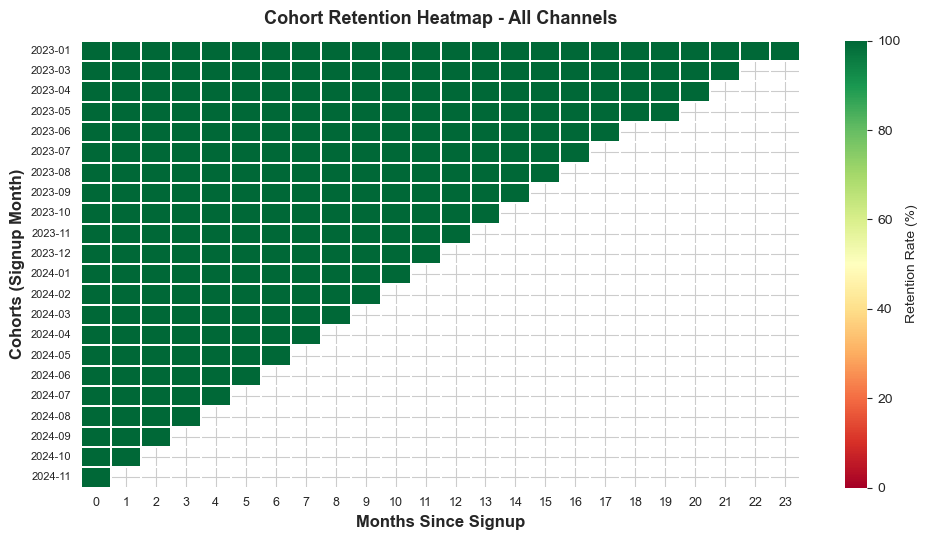

In [4]:
viz.retention_heatmap()

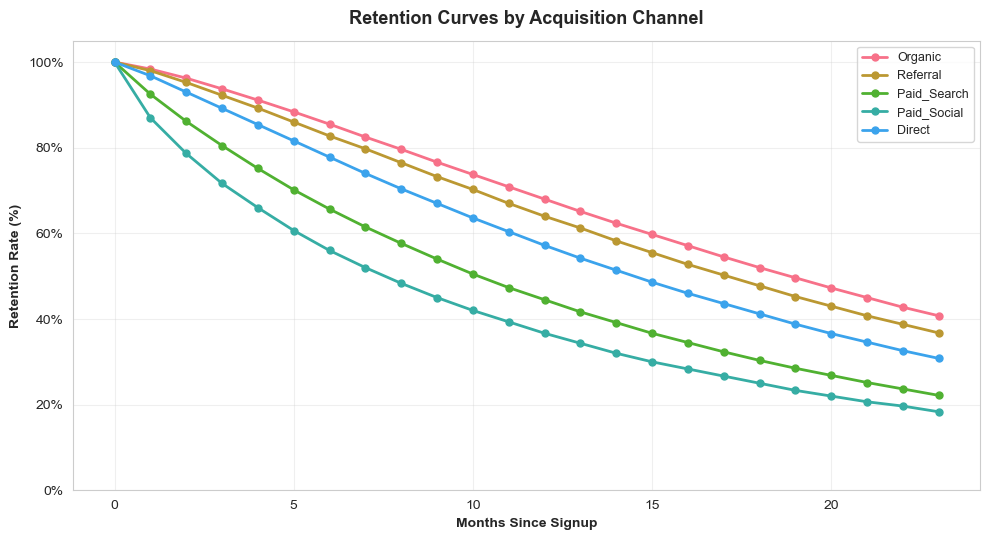

In [5]:
viz.retention_curves_by_channel()

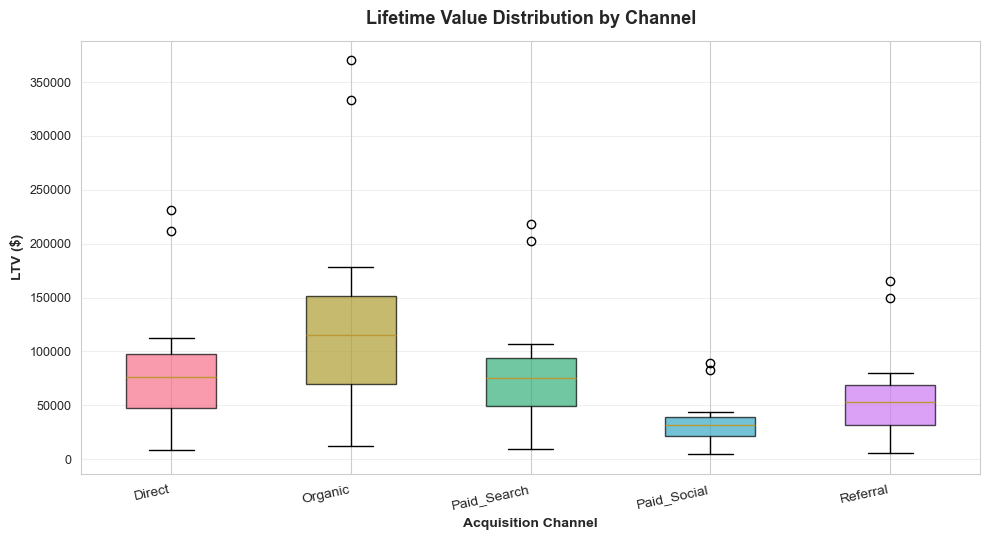

In [6]:
viz.ltv_by_channel_boxplot()

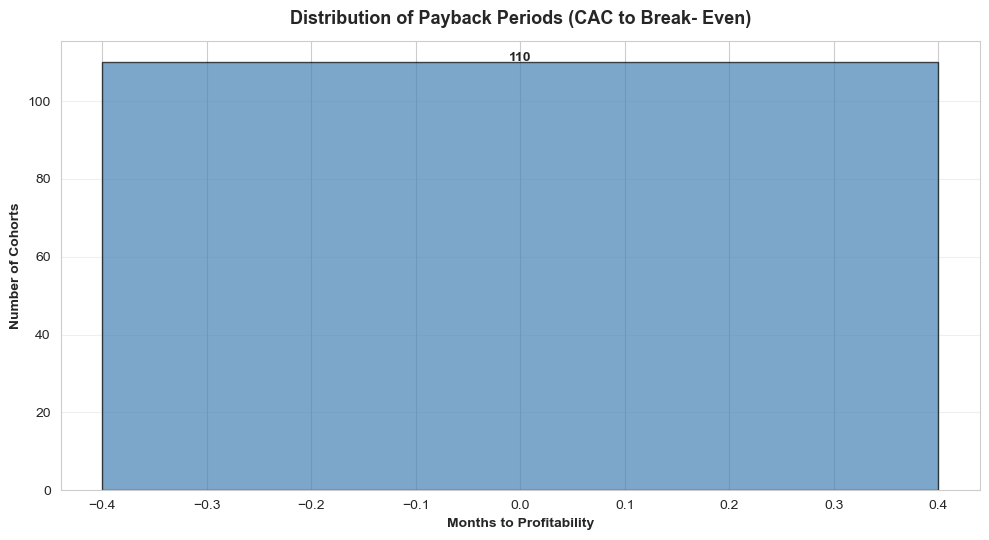

In [7]:
viz.payback_period_distribution()

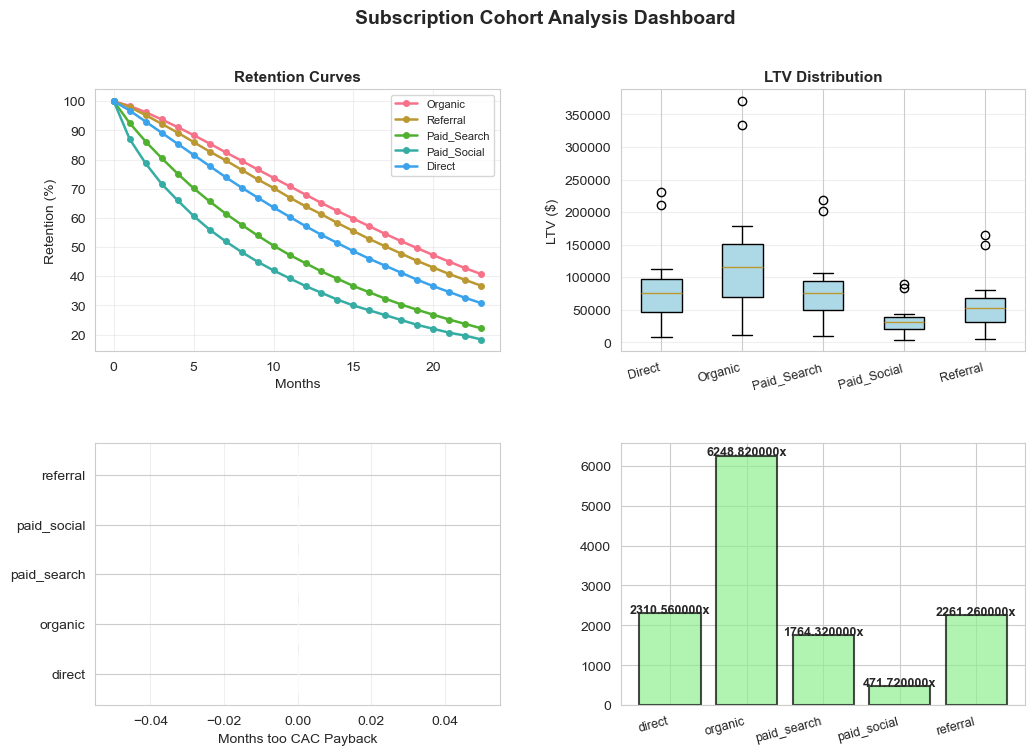

In [8]:
viz.channel_comparison_dashboard()


Generating visualizations to visualizations/n...
Saved retention heatmap to visualizations/n01_retention_heatmap_organic.png
Saved retention heatmap to visualizations/n01_retention_heatmap_referral.png
Saved retention heatmap to visualizations/n01_retention_heatmap_paid_search.png
Saved retention heatmap to visualizations/n01_retention_heatmap_paid_social.png
Saved retention heatmap to visualizations/n01_retention_heatmap_direct.png
Saved retention curves to visualizations/n02_retention_curves.png
Saved LTV box plot to visualizations/n03_ltv_boxplot.png
Saved profitability heatmap to visualizations/n04_profitability_heatmap.png
Saved payback distribution to visualizations/n05_payback_distribution.png
Saved Dashboard to visualizations/n06_dashboard.png
All visualizations generated successfully!


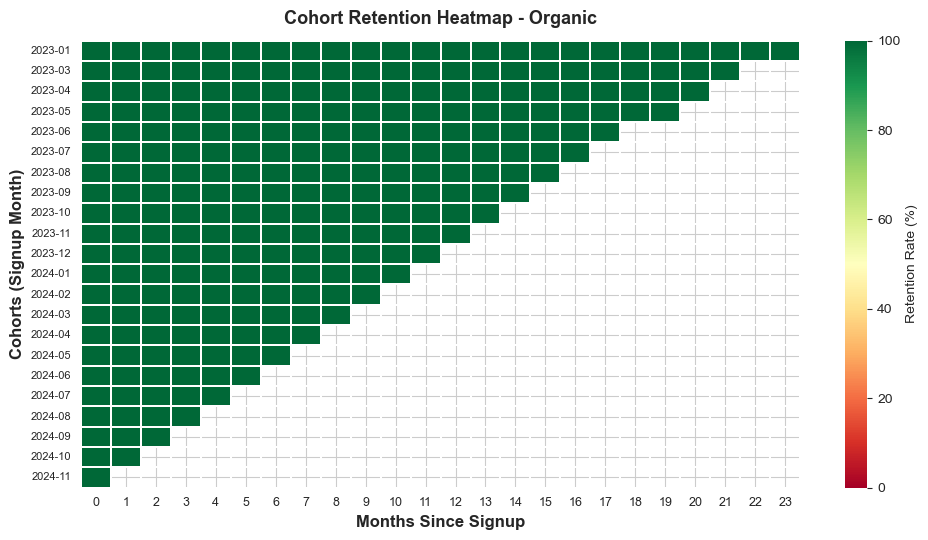

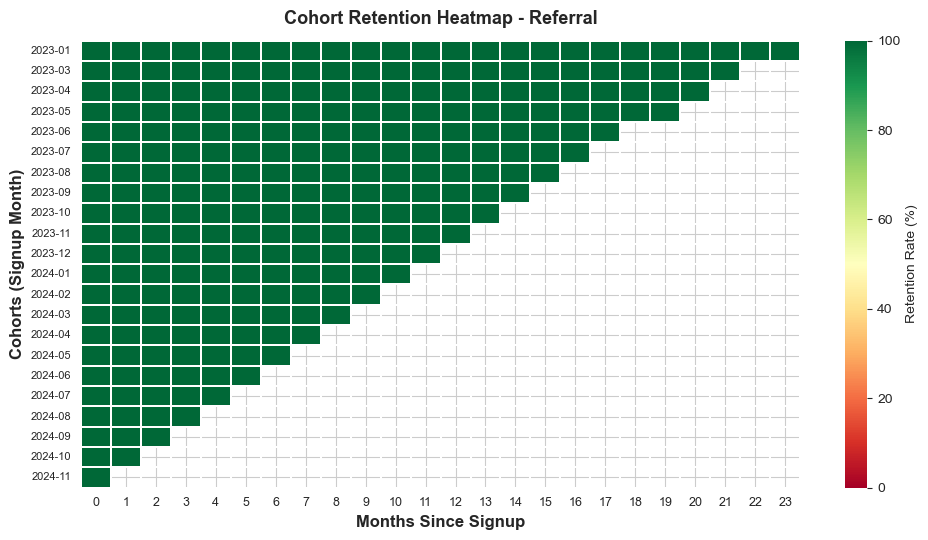

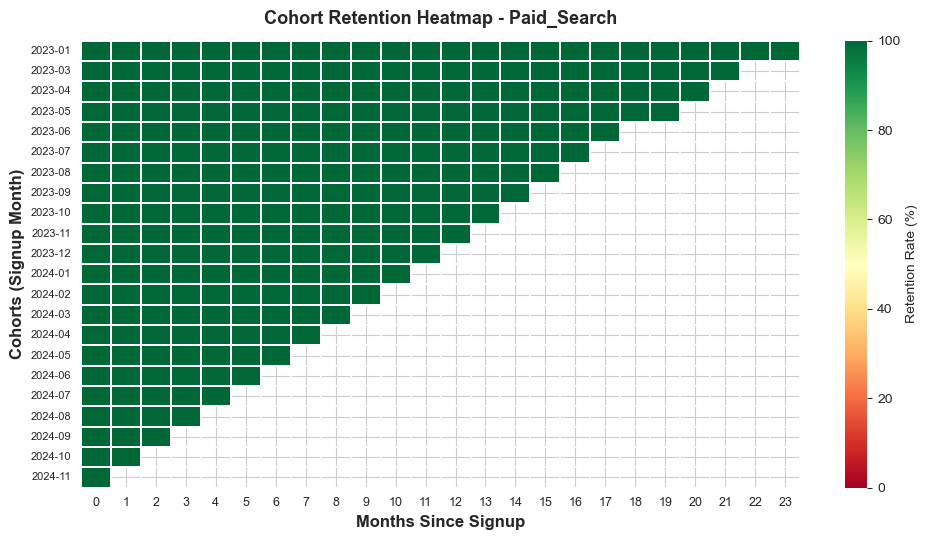

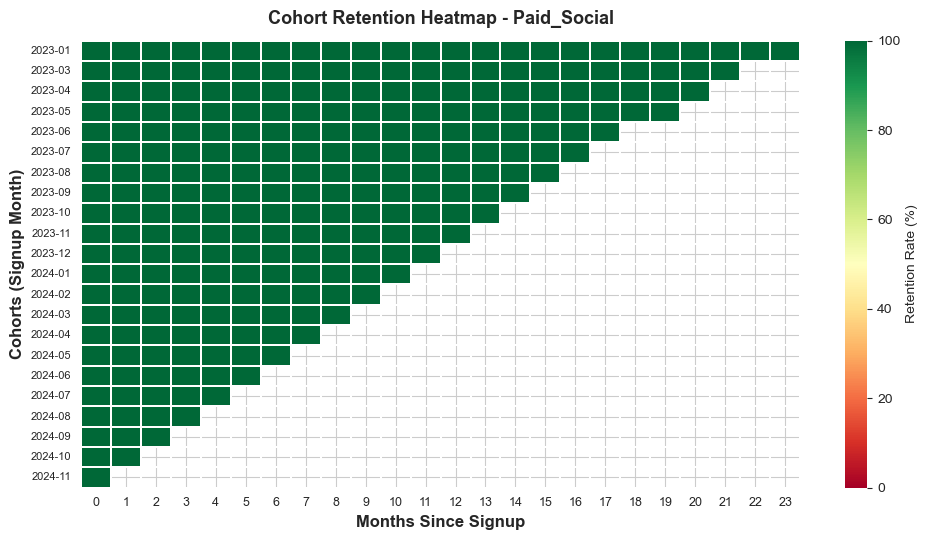

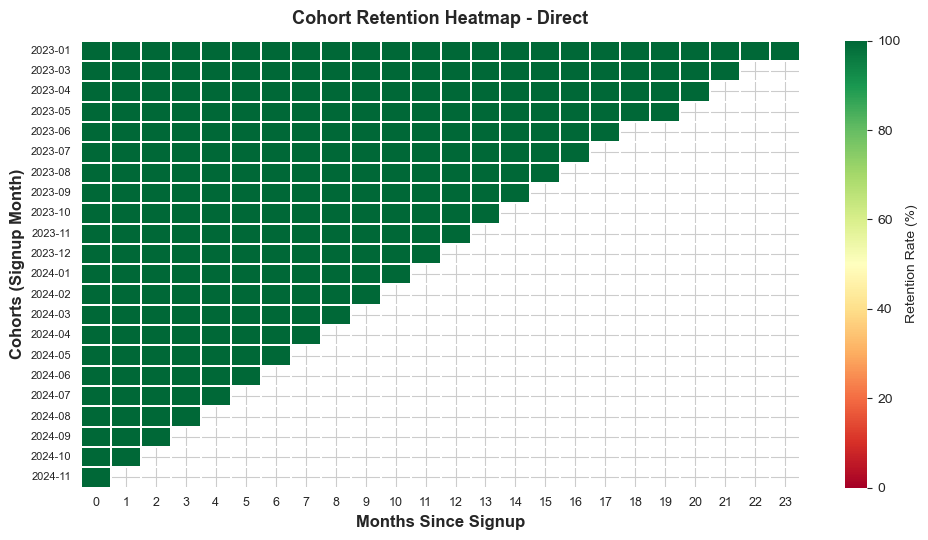

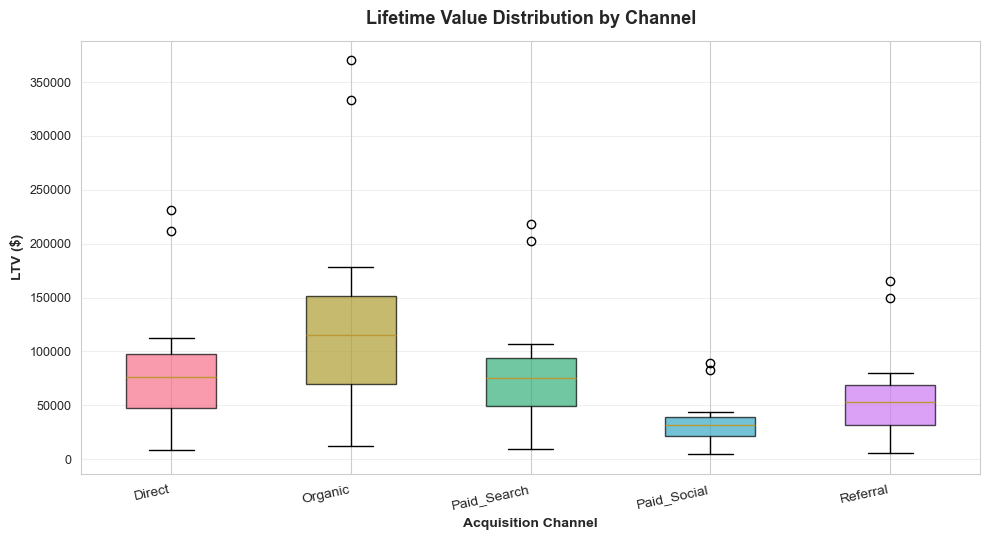

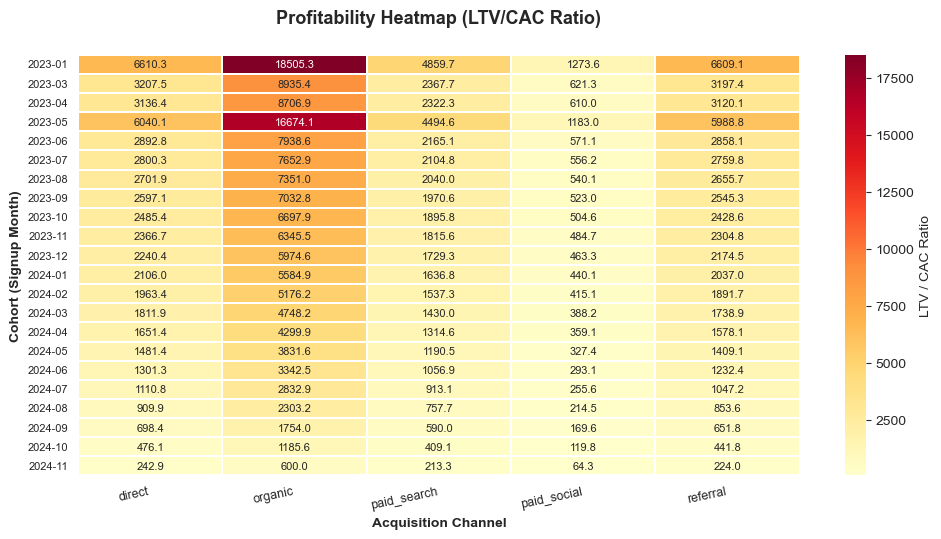

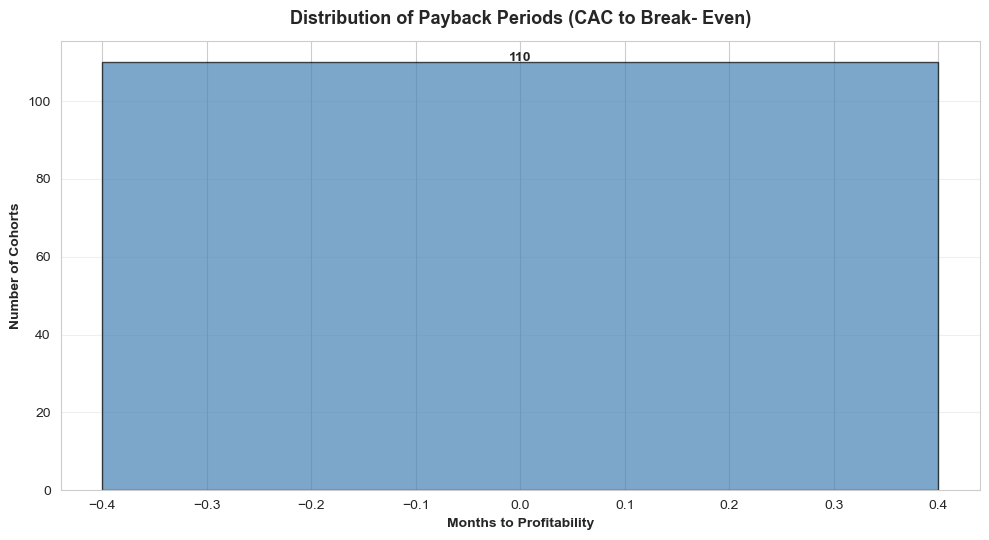

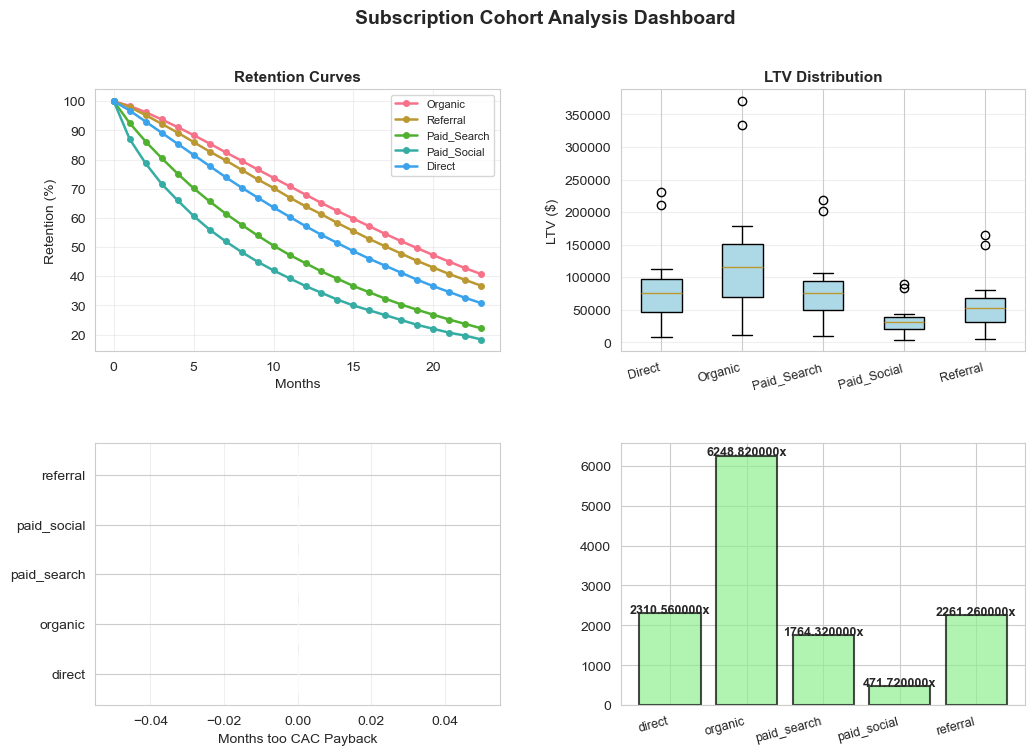

In [123]:
viz.generate_all_visualizations('visualizations/n')
plt.show()